# Parte 8: Modelado y Evaluación del Rendimiento
## Riesgo de Contaminación por Nitratos | La Rioja, 2015 - 2025

*Objetivo:* Entrenar, optimizar y evaluar modelos de aprendizaje automático para predecir el riesgo de contaminación por nitratos en aguas subterráneas. El notebook implementa una validación metodológicamente rigurosa: compara modelos base y complejos con y sin ponderación de clases; realiza un ajuste de hiperparámetros estructurado; evalúa la robustez mediante validaciones temporal y espacial (por punto de monitoreo); y finalmente realiza una evaluación única sobre el conjunto de test completamente aislado. El análisis culmina con la explicabilidad global e individual del modelo final.

### 1. Importación de Librerías y Configuración General
Cargamos las librerías necesarias para el modelado, validación cruzada, métricas de rendimiento y explicabilidad (SHAP).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV, cross_val_predict, StratifiedGroupKFold
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score, balanced_accuracy_score, precision_score, recall_score, make_scorer
from sklearn.inspection import permutation_importance
import shap

# Desactivamos advertencias para una presentación limpia
import warnings
warnings.filterwarnings('ignore')

### 2. Carga de Datos y Metadatos
Cargamos los datasets y metadatos resultantes del preprocesamiento metodológico.

In [2]:
BASE_DIR = Path(r"C:\Users\mcangulo\OneDrive - FEDERACION DE EMPRESAS DE LA RIOJA\Escritorio\dataset_larioja")
carpeta_datos = BASE_DIR / '10_preprocesado_modelado'

X_train = pd.read_csv(carpeta_datos / 'train' / 'X_train_larioja.csv')
X_test  = pd.read_csv(carpeta_datos / 'test'  / 'X_test_larioja.csv')
y_train = pd.read_csv(carpeta_datos / 'train' / 'y_train_larioja.csv').squeeze()
y_test  = pd.read_csv(carpeta_datos / 'test'  / 'y_test_larioja.csv').squeeze()
metadata_train = pd.read_csv(carpeta_datos / 'train' / 'metadata_train.csv')
metadata_test  = pd.read_csv(carpeta_datos / 'test'  / 'metadata_test.csv')

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Distribución original de target en train:\n", y_train.value_counts())

X_train: (937, 104) | X_test: (235, 104)
Distribución original de target en train:
 clase
afectada    472
normal      328
riesgo      137
Name: count, dtype: int64


### 3. Codificación de la Variable Objetivo
Utilizamos `LabelEncoder` sobre el conjunto de entrenamiento para transformar las clases categóricas (`afectada`, `normal`, `riesgo`) en etiquetas numéricas discretas, requeridas para XGBoost.

In [3]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Codificación de clases:")
for clase, codigo in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {clase} → {codigo}")

Codificación de clases:
  afectada → 0
  normal → 1
  riesgo → 2


### 4. Modelo Dummy de Referencia (Baseline)
Entrenamos un clasificador Dummy que predice sistemáticamente la clase más frecuente. Este modelo sirve para establecer un piso mínimo de rendimiento y demostrar por qué la métrica de `accuracy` por sí sola es insuficiente en presencia de datos desbalanceados.

In [4]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train_enc)
y_pred_dummy = dummy.predict(X_test)

print("=== RENDIMIENTO DEL MODELO DUMMY (TEST SET) ===")
print(f"Accuracy: {accuracy_score(y_test_enc, y_pred_dummy):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_enc, y_pred_dummy):.4f}")
print(f"F1 Macro: {f1_score(y_test_enc, y_pred_dummy, average='macro'):.4f}")
print("\nReporte de clasificación detallado:")
print(classification_report(y_test_enc, y_pred_dummy, target_names=le.classes_, zero_division=0))

=== RENDIMIENTO DEL MODELO DUMMY (TEST SET) ===
Accuracy: 0.5064
Balanced Accuracy: 0.3333
F1 Macro: 0.2241

Reporte de clasificación detallado:
              precision    recall  f1-score   support

    afectada       0.51      1.00      0.67       119
      normal       0.00      0.00      0.00        82
      riesgo       0.00      0.00      0.00        34

    accuracy                           0.51       235
   macro avg       0.17      0.33      0.22       235
weighted avg       0.26      0.51      0.34       235



### 5. Definición de Clase XGBoost Ponderada Compatible con Scikit-Learn
Debido a que `XGBClassifier` no expone una opción nativa `class_weight='balanced'` para clasificación multiclase, implementamos una clase personalizada que hereda de `XGBClassifier` y calcula dinámicamente los pesos balanceados (`sample_weight`) de la muestra en cada fold de validación cruzada. Esto previene la fuga de información que ocurriría si calculáramos los pesos sobre todo el conjunto de forma estática.

In [5]:
class BalancedXGBClassifier(XGBClassifier):
    def fit(self, X, y, sample_weight=None, **fit_params):
        # Calculamos los pesos de la muestra basados estrictamente en el target de entrenamiento del fold
        sw = compute_sample_weight(class_weight="balanced", y=y)
        return super().fit(X, y, sample_weight=sw, **fit_params)

### 6. Comparación de Modelos con y sin Ponderación (Validación Cruzada)
Realizamos una validación cruzada estratificada de 5 folds sobre el conjunto de entrenamiento. Comparamos seis configuraciones distintas, evaluando los modelos de Regresión Logística, Random Forest y XGBoost con y sin ponderación de clases. 

El conjunto de prueba se mantiene estrictamente aislado en este paso.

In [6]:
# Definición del scorer personalizado para registrar el F1 de la clase minoritaria 'riesgo' (código 2)
def f1_riesgo_func(y_true, y_pred):
    f1_vals = f1_score(y_true, y_pred, average=None, labels=[2], zero_division=0)
    return f1_vals[0] if len(f1_vals) > 0 else 0.0

f1_riesgo_scorer = make_scorer(f1_riesgo_func)

# Diccionario de métricas para la validación cruzada
scorers = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_riesgo': f1_riesgo_scorer
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_config = {
    "LR sin ponderación": LogisticRegression(max_iter=5000, random_state=42),
    "LR ponderada (balanced)": LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced"),
    "RF sin ponderación": RandomForestClassifier(n_estimators=200, random_state=42),
    "RF ponderado (balanced)": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "XGB sin ponderación": XGBClassifier(random_state=42, eval_metric="mlogloss"),
    "XGB ponderado (sample_weight)": BalancedXGBClassifier(random_state=42, eval_metric="mlogloss")
}

cv_results_list = []

for name, model in models_config.items():
    res = cross_validate(model, X_train, y_train_enc, cv=cv, scoring=scorers, return_train_score=False)
    cv_results_list.append({
        "Configuración": name,
        "F1 Macro (Mean)": np.mean(res["test_f1_macro"]),
        "F1 Macro (Std)": np.std(res["test_f1_macro"]),
        "Accuracy (Mean)": np.mean(res["test_accuracy"]),
        "Balanced Acc (Mean)": np.mean(res["test_balanced_accuracy"]),
        "Precision Macro (Mean)": np.mean(res["test_precision_macro"]),
        "Recall Macro (Mean)": np.mean(res["test_recall_macro"]),
        "F1 Riesgo (Mean)": np.mean(res["test_f1_riesgo"])
    })

df_cv_results = pd.DataFrame(cv_results_list)
print("=== RESULTADOS DE VALIDACIÓN CRUZADA EN EL CONJUNTO DE ENTRENAMIENTO ===")
print(df_cv_results.to_string(index=False))

=== RESULTADOS DE VALIDACIÓN CRUZADA EN EL CONJUNTO DE ENTRENAMIENTO ===
                Configuración  F1 Macro (Mean)  F1 Macro (Std)  Accuracy (Mean)  Balanced Acc (Mean)  Precision Macro (Mean)  Recall Macro (Mean)  F1 Riesgo (Mean)
           LR sin ponderación         0.754695        0.036987         0.829252             0.746919                0.768942             0.746919          0.505123
      LR ponderada (balanced)         0.746333        0.012563         0.788696             0.775956                0.747203             0.775956          0.535132
           RF sin ponderación         0.788033        0.033584         0.847383             0.784928                0.793783             0.784928          0.579513
      RF ponderado (balanced)         0.788457        0.027733         0.848470             0.783128                0.797131             0.783128          0.583331
          XGB sin ponderación         0.789418        0.029782         0.855928             0.782032       

### 7. Selección del Mejor Modelo Candidato
La selección se basa en: 
1. **F1 Macro Medio:** Métrica principal del proyecto para asegurar un rendimiento equilibrado en todas las clases.
2. **Estabilidad del F1 Macro (Std):** Menores desviaciones estándar indican que el modelo generaliza consistentemente.
3. **F1 Medio de la clase `riesgo`:** Prioridad ambiental, ya que identificar el riesgo de contaminación es clave.

De acuerdo con los resultados de la validación cruzada, **XGBoost ponderado** muestra el mejor rendimiento promedio, con el mayor F1 Macro (cercano a 0.81) y una detección robusta de la clase `riesgo` (F1 ~ 0.61). Procederemos a optimizar los hiperparámetros de esta arquitectura.

### 8. Ajuste de Hiperparámetros (RandomizedSearchCV)
Optimizamos los hiperparámetros de XGBoost utilizando una búsqueda aleatoria (`RandomizedSearchCV`) con 50 iteraciones y validación cruzada estratificada de 5 folds. Realizamos este proceso tanto para la versión sin ponderación como para la versión ponderada para comparar de forma justa el impacto de la calibración hiperparamétrica.

In [7]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0]
}

print("Ajustando XGBoost sin ponderar...")
search_no_weight = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1
)
search_no_weight.fit(X_train, y_train_enc)

print("Ajustando XGBoost ponderado...")
search_weighted = RandomizedSearchCV(
    BalancedXGBClassifier(random_state=42, eval_metric="mlogloss"),
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1
)
search_weighted.fit(X_train, y_train_enc)

print(f"\nMejor F1 Macro XGB sin ponderar: {search_no_weight.best_score_:.4f}")
print(f"Mejor F1 Macro XGB ponderado:    {search_weighted.best_score_:.4f}")

# Selección final de la estrategia ganadora
if search_weighted.best_score_ >= search_no_weight.best_score_:
    best_estimator = search_weighted.best_estimator_
    best_params = search_weighted.best_params_
    best_score = search_weighted.best_score_
    best_std = search_weighted.cv_results_['std_test_score'][search_weighted.best_index_]
    weight_strategy = "weighted"
    print("\nConfiguración seleccionada: XGBoost Optimizado con Ponderación de Clases.")
else:
    best_estimator = search_no_weight.best_estimator_
    best_params = search_no_weight.best_params_
    best_score = search_no_weight.best_score_
    best_std = search_no_weight.cv_results_['std_test_score'][search_no_weight.best_index_]
    weight_strategy = "no_weight"
    print("\nConfiguración seleccionada: XGBoost Optimizado sin Ponderación.")

Ajustando XGBoost sin ponderar...
Ajustando XGBoost ponderado...

Mejor F1 Macro XGB sin ponderar: 0.8052
Mejor F1 Macro XGB ponderado:    0.8212

Configuración seleccionada: XGBoost Optimizado con Ponderación de Clases.


Ajustando XGBoost ponderado...



Mejor F1 Macro XGB sin ponderar: 0.8074
Mejor F1 Macro XGB ponderado:    0.8314

Configuración seleccionada: XGBoost Optimizado con Ponderación de Clases.


### 9. Predicciones Out-of-Fold (OOF)
Para analizar el desempeño interno y la capacidad de generalización del mejor modelo ajustado, generamos predicciones Out-of-Fold sobre el conjunto de entrenamiento mediante validación cruzada. Esto simula el rendimiento sobre datos no vistos de forma interna y nos permite inspeccionar errores.

In [8]:
y_pred_oof = cross_val_predict(best_estimator, X_train, y_train_enc, cv=cv)

print("=== REPORTE DE CLASIFICACIÓN OUT-OF-FOLD (TRAIN SET) ===")
print(classification_report(y_train_enc, y_pred_oof, target_names=le.classes_))

cm_oof = confusion_matrix(y_train_enc, y_pred_oof)
df_cm_oof = pd.DataFrame(cm_oof, index=[f"real_{c}" for c in le.classes_], columns=[f"pred_{c}" for c in le.classes_])
print("Matriz de Confusión Out-of-Fold:\n", df_cm_oof)

=== REPORTE DE CLASIFICACIÓN OUT-OF-FOLD (TRAIN SET) ===
              precision    recall  f1-score   support

    afectada       0.93      0.86      0.90       472
      normal       0.91      0.90      0.90       328
      riesgo       0.58      0.74      0.65       137

    accuracy                           0.86       937
   macro avg       0.81      0.83      0.82       937
weighted avg       0.87      0.86      0.86       937

Matriz de Confusión Out-of-Fold:
                pred_afectada  pred_normal  pred_riesgo
real_afectada            408           15           49
real_normal                8          295           25
real_riesgo               22           14          101


### 10. Validación Temporal
Utilizando los metadatos temporales extraídos, dividimos cronológicamente el conjunto de entrenamiento. Definimos como entrenamiento los registros históricos anteriores o iguales al año 2024 (775 muestras) y como validación los registros de 2025 (162 muestras). 

Esta validación evalúa la capacidad de generalización temporal del modelo a futuros años de monitoreo.

In [9]:
temporal_train_mask = metadata_train["anio"] <= 2024
X_temp_train = X_train[temporal_train_mask]
y_temp_train = y_train_enc[temporal_train_mask]
X_temp_val = X_train[~temporal_train_mask]
y_temp_val = y_train_enc[~temporal_train_mask]

print(f"Muestras de entrenamiento temporal (<= 2024): {X_temp_train.shape[0]}")
print(f"Muestras de validación temporal (2025):     {X_temp_val.shape[0]}")

# Entrenamos e inicializamos una instancia con la misma configuración ganadora
if weight_strategy == "weighted":
    temp_model = BalancedXGBClassifier(**best_params, random_state=42, eval_metric="mlogloss")
else:
    temp_model = XGBClassifier(**best_params, random_state=42, eval_metric="mlogloss")

temp_model.fit(X_temp_train, y_temp_train)
y_pred_temp = temp_model.predict(X_temp_val)

print("\n=== REPORTE DE RENDIMIENTO - VALIDACIÓN TEMPORAL (2025) ===")
print(classification_report(y_temp_val, y_pred_temp, target_names=le.classes_, zero_division=0))

Muestras de entrenamiento temporal (<= 2024): 775
Muestras de validación temporal (2025):     162

=== REPORTE DE RENDIMIENTO - VALIDACIÓN TEMPORAL (2025) ===
              precision    recall  f1-score   support

    afectada       0.88      0.66      0.76        68
      normal       0.89      0.93      0.91        70
      riesgo       0.47      0.75      0.58        24

    accuracy                           0.79       162
   macro avg       0.75      0.78      0.75       162
weighted avg       0.83      0.79      0.80       162




=== REPORTE DE RENDIMIENTO - VALIDACIÓN TEMPORAL (2025) ===
              precision    recall  f1-score   support

    afectada       0.91      0.74      0.81        68
      normal       0.93      0.94      0.94        70
      riesgo       0.50      0.75      0.60        24

    accuracy                           0.83       162
   macro avg       0.78      0.81      0.78       162
weighted avg       0.86      0.83      0.83       162



### 11. Validación Espacial Agrupada por Punto de Monitoreo (IPA)
Evaluamos la capacidad de generalización espacial del modelo utilizando `StratifiedGroupKFold` con 5 pliegues, agrupando los registros por el punto de monitoreo (`ipa`). 

Esta validación mide si el modelo es capaz de predecir correctamente la contaminación en pozos o acuíferos nuevos que nunca han suministrado observaciones al modelo durante su entrenamiento.

In [10]:
group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
groups_train = metadata_train["ipa"]

res_group = cross_validate(best_estimator, X_train, y_train_enc, cv=group_cv, groups=groups_train, scoring=scorers)

print("=== RENDIMIENTO DE VALIDACIÓN ESPACIAL POR IPA (GRUPO) ===")
print(f"F1 Macro (Spatial Mean): {np.mean(res_group['test_f1_macro']):.4f} (+/- {np.std(res_group['test_f1_macro']):.4f})")
print(f"Accuracy (Spatial Mean): {np.mean(res_group['test_accuracy']):.4f}")
print(f"F1 Riesgo (Spatial Mean): {np.mean(res_group['test_f1_riesgo']):.4f} (+/- {np.std(res_group['test_f1_riesgo']):.4f})")

=== RENDIMIENTO DE VALIDACIÓN ESPACIAL POR IPA (GRUPO) ===
F1 Macro (Spatial Mean): 0.5831 (+/- 0.0668)
Accuracy (Spatial Mean): 0.6809
F1 Riesgo (Spatial Mean): 0.2475 (+/- 0.1023)


> **Diferencia Crítica de Rendimiento**
>
> - **Validación Cruzada Estratificada:** el modelo obtuvo un F1 macro aproximado de 0,81. Este resultado muestra un buen desempeño interno; sin embargo, al no separar las observaciones por punto de monitoreo, un mismo IPA puede aportar registros tanto al entrenamiento como a la validación. Por ello, esta evaluación puede resultar optimista respecto a la capacidad del modelo para aplicarse en ubicaciones completamente nuevas.
> - **Validación Temporal:** Eal entrenar con registros hasta 2024 y evaluar con observaciones de 2025, el modelo alcanzó un F1 macro de aproximadamente 0,75. El descenso moderado indica que los patrones aprendidos conservan utilidad para un periodo posterior, aunque la capacidad de generalización disminuye ante cambios temporales.
> - **Validación Espacial (GroupKFold por IPA):** al mantener juntas todas las observaciones de cada punto de monitoreo y evaluar el modelo sobre IPA no vistos durante el entrenamiento, el F1 macro descendió a aproximadamente 0,58, mientras que el F1 de la clase riesgo se redujo a cerca de 0,25. Este resultado evidencia que la principal limitación del modelo es la generalización hacia puntos de monitoreo nuevos.
>
>  En conjunto, los resultados indican que el modelo predice mejor nuevas observaciones de ubicaciones previamente representadas que observaciones procedentes de puntos completamente desconocidos. Esto sugiere que las variables ambientales integradas contienen información predictiva, pero no capturan por completo las condiciones locales que determinan la concentración de nitratos en cada punto, como las características hidrogeológicas, la profundidad de la captación o las presiones agrícolas específicas.

### 12. Evaluación Final Única sobre el Conjunto de Test (Holdout Set)
Una vez ajustado y validado el modelo, rompemos el aislamiento del conjunto de prueba por primera y única vez. Entrenamos el mejor modelo optimizado con la totalidad de `X_train` y evaluamos sobre `X_test` para obtener estimaciones imparciales de generalización final.

In [11]:
# Entrenamos el modelo optimizado con todo el conjunto de entrenamiento
best_estimator.fit(X_train, y_train_enc)
y_pred_test = best_estimator.predict(X_test)

acc_test = accuracy_score(y_test_enc, y_pred_test)
bal_acc_test = balanced_accuracy_score(y_test_enc, y_pred_test)
f1_macro_test = f1_score(y_test_enc, y_pred_test, average="macro")
prec_macro_test = precision_score(y_test_enc, y_pred_test, average="macro")
rec_macro_test = recall_score(y_test_enc, y_pred_test, average="macro")
f1_clases_test = f1_score(y_test_enc, y_pred_test, average=None)

prec_riesgo_test = precision_score(y_test_enc, y_pred_test, average=None)[2]
rec_riesgo_test = recall_score(y_test_enc, y_pred_test, average=None)[2]
f1_riesgo_test = f1_clases_test[2]

print("=== EVALUACIÓN DE GENERALIZACIÓN FINAL INDEPENDIENTE (TEST SET) ===")
print(f"Accuracy:          {acc_test:.4f}")
print(f"Balanced Accuracy: {bal_acc_test:.4f}")
print(f"Precision Macro:   {prec_macro_test:.4f}")
print(f"Recall Macro:      {rec_macro_test:.4f}")
print(f"F1 Macro:          {f1_macro_test:.4f}")
print(f"F1 afectada:       {f1_clases_test[0]:.4f}")
print(f"F1 normal:         {f1_clases_test[1]:.4f}")
print(f"F1 riesgo:         {f1_clases_test[2]:.4f}")
print(f"Precision riesgo:  {prec_riesgo_test:.4f} | Recall riesgo: {rec_riesgo_test:.4f}")

cm_test = confusion_matrix(y_test_enc, y_pred_test)
cm_test_norm = confusion_matrix(y_test_enc, y_pred_test, normalize="true")

df_cm_test = pd.DataFrame(cm_test, index=[f"real_{c}" for c in le.classes_], columns=[f"pred_{c}" for c in le.classes_])
print("\nMatriz de Confusión en Test:\n", df_cm_test)

df_cm_test_norm = pd.DataFrame(cm_test_norm, index=[f"real_{c}" for c in le.classes_], columns=[f"pred_{c}" for c in le.classes_])
print("\nMatriz de Confusión Normalizada en Test:\n", df_cm_test_norm.round(3))

=== EVALUACIÓN DE GENERALIZACIÓN FINAL INDEPENDIENTE (TEST SET) ===
Accuracy:          0.8383
Balanced Accuracy: 0.8173
Precision Macro:   0.7875
Recall Macro:      0.8173
F1 Macro:          0.7916
F1 afectada:       0.9130
F1 normal:         0.8571
F1 riesgo:         0.6047
Precision riesgo:  0.5000 | Recall riesgo: 0.7647

Matriz de Confusión en Test:
                pred_afectada  pred_normal  pred_riesgo
real_afectada            105            2           12
real_normal                2           66           14
real_riesgo                4            4           26

Matriz de Confusión Normalizada en Test:
                pred_afectada  pred_normal  pred_riesgo
real_afectada          0.882        0.017        0.101
real_normal            0.024        0.805        0.171
real_riesgo            0.118        0.118        0.765


### 13. Comparación y Resumen de Métricas del Pipeline
Consolidamos una tabla resumen que compara todas las etapas de validación del pipeline del mejor modelo candidato seleccionado para una integración directa en el manuscrito del TFM.

In [12]:
metricas_pipeline = pd.DataFrame({
    "Etapa de Validación": [
        "Validación Cruzada Estratificada (CV-5)",
        "Predicciones Out-of-Fold (OOF)",
        "Validación Temporal (2025)",
        "Validación Espacial (GroupKFold por IPA)",
        "Evaluación Final Independiente (Test)"
    ],
    "Accuracy": [
        np.mean(res["test_accuracy"]),
        accuracy_score(y_train_enc, y_pred_oof),
        accuracy_score(y_temp_val, y_pred_temp),
        np.mean(res_group["test_accuracy"]),
        acc_test
    ],
    "F1 Macro": [
        best_score,
        f1_score(y_train_enc, y_pred_oof, average="macro"),
        f1_score(y_temp_val, y_pred_temp, average="macro"),
        np.mean(res_group["test_f1_macro"]),
        f1_macro_test
    ],
    "F1 Riesgo (Minoritario)": [
        np.mean(res["test_f1_riesgo"]),
        f1_score(y_train_enc, y_pred_oof, average=None)[2],
        f1_score(y_temp_val, y_pred_temp, average=None)[2],
        np.mean(res_group["test_f1_riesgo"]),
        f1_riesgo_test
    ]
})
print(metricas_pipeline.round(4).to_string(index=False))

                     Etapa de Validación  Accuracy  F1 Macro  F1 Riesgo (Minoritario)
 Validación Cruzada Estratificada (CV-5)    0.8656    0.8212                   0.6167
          Predicciones Out-of-Fold (OOF)    0.8581    0.8163                   0.6474
              Validación Temporal (2025)    0.7901    0.7487                   0.5806
Validación Espacial (GroupKFold por IPA)    0.6809    0.5831                   0.2475
   Evaluación Final Independiente (Test)    0.8383    0.7916                   0.6047


### 14. Explicabilidad del Mejor Modelo (Caja Negra)
Analizamos qué factores determinan las decisiones del modelo desde tres enfoques complementarios: importancia interna del algoritmo, importancia por permutación y valores SHAP.

#### 14.1 Importancia Interna del Algoritmo
Representa la ganancia promedio aportada por cada variable al construir los árboles en XGBoost.

In [13]:
importances_int = best_estimator.feature_importances_
df_imp_int = pd.DataFrame({
    "variable": X_train.columns,
    "importancia": importances_int
})
df_imp_int["porcentaje"] = (df_imp_int["importancia"] / df_imp_int["importancia"].sum()) * 100
df_imp_int = df_imp_int.sort_values("porcentaje", ascending=False).reset_index(drop=True)
df_imp_int["porcentaje_acumulado"] = df_imp_int["porcentaje"].cumsum()

print("=== TOP 20 VARIABLES POR IMPORTANCIA INTERNA DEL MODELO ===")
print(df_imp_int.head(20).to_string(index=False))

=== TOP 20 VARIABLES POR IMPORTANCIA INTERNA DEL MODELO ===
                               variable  importancia  porcentaje  porcentaje_acumulado
               zona_vulnerable_nitratos     0.056013    5.601300              5.601300
        clc2018_nombre_Bosque frondosas     0.041280    4.127999              9.729300
                       soil_clay_5_15cm     0.040213    4.021348             13.750647
                      soil_clay_15_30cm     0.027383    2.738312             16.488958
        clc2018_nombre_Terrenos regados     0.022942    2.294226             18.783184
                          altitud_dem_m     0.022038    2.203850             20.987034
                        soil_cec_5_15cm     0.021781    2.178122             23.165155
        sigpac_uso_nombre_Tierra arable     0.021415    2.141525             25.306681
sigpac_uso_nombre_Monte bajo / Matorral     0.020442    2.044172             27.350853
                        soil_clay_0_5cm     0.018685    1.868546      

#### 14.2 Importancia por Permutación
Mide la caída en el F1 Macro en el conjunto de test cuando barajamos aleatoriamente cada variable de forma individual. Muestra qué variables causan la mayor degradación en las predicciones si se destruye su información.

In [14]:
print("Calculando Permutation Importance (20 repeticiones)...")
perm_imp = permutation_importance(
    best_estimator, X_test, y_test_enc, 
    scoring="f1_macro", n_repeats=20, 
    random_state=42, n_jobs=-1
)

df_imp_perm = pd.DataFrame({
    "variable": X_train.columns,
    "importancia_permutacion": perm_imp.importances_mean,
    "std_permutacion": perm_imp.importances_std
})

# Porcentaje relativo para variables con aportación positiva
total_pos = df_imp_perm[df_imp_perm["importancia_permutacion"] > 0]["importancia_permutacion"].sum()
df_imp_perm["porcentaje_relativo"] = np.where(
    df_imp_perm["importancia_permutacion"] > 0,
    (df_imp_perm["importancia_permutacion"] / total_pos) * 100,
    0.0
)

df_imp_perm = df_imp_perm.sort_values("importancia_permutacion", ascending=False).reset_index(drop=True)
print("\n=== TOP 20 VARIABLES POR IMPORTANCIA DE PERMUTACIÓN ===")
print(df_imp_perm.head(20).to_string(index=False))

Calculando Permutation Importance (20 repeticiones)...

=== TOP 20 VARIABLES POR IMPORTANCIA DE PERMUTACIÓN ===
                       variable  importancia_permutacion  std_permutacion  porcentaje_relativo
       zona_vulnerable_nitratos                 0.149062         0.016532            67.445449
                           anio                 0.023054         0.012114            10.431137
                 temp_media_30d                 0.005368         0.007423             2.428854
                        y_utm30                 0.005045         0.008302             2.282579
                      precip_7d                 0.004615         0.006076             2.088063
clc2018_nombre_Terrenos regados                 0.004086         0.001716             1.848580
clc2012_nombre_Terrenos regados                 0.004086         0.001716             1.848580
                     precip_15d                 0.003576         0.005505             1.618168
             soil_wv1500_5_15cm  


=== TOP 20 VARIABLES POR IMPORTANCIA DE PERMUTACIÓN ===
                           variable  importancia_permutacion  std_permutacion  porcentaje_relativo
           zona_vulnerable_nitratos                 0.135069         0.015510            40.536591
                               anio                 0.041834         0.012839            12.555150
                      altitud_dem_m                 0.029037         0.014148             8.714626
                               tmed                 0.012158         0.005182             3.648919
                         precip_30d                 0.009557         0.006435             2.868172
               sigpac_superficie_m2                 0.008879         0.005306             2.664854
                          precip_7d                 0.008665         0.007049             2.600448
                     temp_media_30d                 0.008440         0.011987             2.532957
      municipio_CASTAÑARES DE RIOJA                 

#### 14.3 Importancia mediante Valores SHAP
Calculamos la explicabilidad aditiva mediante la teoría de juegos (valores SHAP). Obtenemos la contribución de cada variable tanto a nivel global como individualizada por clase.

In [15]:
print("Calculando valores SHAP con TreeExplainer...")
explainer = shap.TreeExplainer(best_estimator)
shap_values = explainer.shap_values(X_test)

# Comprobamos estructura del output de SHAP (lista para multiclase o array 3D)
if isinstance(shap_values, list):
    mean_abs_per_class = [np.abs(sv).mean(axis=0) for sv in shap_values]
    global_shap_importance = np.mean(mean_abs_per_class, axis=0)
    shap_values_list = shap_values
else:
    if len(shap_values.shape) == 3:
        global_shap_importance = np.abs(shap_values).mean(axis=(0, 2))
        shap_values_list = [shap_values[:, :, c] for c in range(shap_values.shape[2])]
    else:
        global_shap_importance = np.abs(shap_values).mean(axis=0)
        shap_values_list = [shap_values]

# Creamos la tabla SHAP global
df_shap_global = pd.DataFrame({
    "variable": X_train.columns,
    "importancia_shap": global_shap_importance
})
df_shap_global["porcentaje"] = (df_shap_global["importancia_shap"] / df_shap_global["importancia_shap"].sum()) * 100
df_shap_global = df_shap_global.sort_values("importancia_shap", ascending=False).reset_index(drop=True)
df_shap_global["porcentaje_acumulado"] = df_shap_global["porcentaje"].cumsum()

print("=== TOP 20 VARIABLES POR VALOR SHAP GLOBAL ===")
print(df_shap_global.head(20).to_string(index=False))

# Creamos la tabla SHAP por clases
shap_vals_clase_0 = np.abs(shap_values_list[0]).mean(axis=0)
shap_vals_clase_1 = np.abs(shap_values_list[1]).mean(axis=0)
shap_vals_clase_2 = np.abs(shap_values_list[2]).mean(axis=0)

df_shap_classes = pd.DataFrame({
    "variable": X_train.columns,
    "afectada_shap": shap_vals_clase_0,
    "normal_shap": shap_vals_clase_1,
    "riesgo_shap": shap_vals_clase_2
})
print("\n=== VALORES SHAP POR CLASES (TOP 10) ===")
print(df_shap_classes.head(10).to_string(index=False))

Calculando valores SHAP con TreeExplainer...
=== TOP 20 VARIABLES POR VALOR SHAP GLOBAL ===
                variable  importancia_shap  porcentaje  porcentaje_acumulado
zona_vulnerable_nitratos          0.507956   15.171268             15.171268
                    anio          0.178978    5.345570             20.516838
           altitud_dem_m          0.169979    5.076820             25.593658
    sigpac_pendiente_pct          0.143435    4.283999             29.877659
       soil_clay_15_30cm          0.142213    4.247524             34.125183
           anomalia_temp          0.138089    4.124336             38.249519
        soil_clay_5_15cm          0.123572    3.690752             41.940269
         soil_cec_5_15cm          0.104429    3.118999             45.059269
         dist_estacion_m          0.089483    2.672617             47.731888
          temp_media_30d          0.080436    2.402413             50.134300
                 y_utm30          0.079985    2.388922       

=== TOP 20 VARIABLES POR VALOR SHAP GLOBAL ===
                variable  importancia_shap  porcentaje  porcentaje_acumulado
zona_vulnerable_nitratos          0.509208   17.117121             17.117121
           altitud_dem_m          0.172941    5.813437             22.930557
                    anio          0.155159    5.215714             28.146271
    sigpac_pendiente_pct          0.148168    4.980698             33.126968
       soil_clay_15_30cm          0.112036    3.766119             36.893089
        soil_clay_5_15cm          0.110807    3.724799             40.617889
           anomalia_temp          0.095178    3.199437             43.817326
                 y_utm30          0.078132    2.626421             46.443748
         soil_cec_5_15cm          0.074976    2.520322             48.964069
         soil_clay_0_5cm          0.072832    2.448267             51.412334
         dist_estacion_m          0.069900    2.349700             53.762035
          temp_media_30d     

#### 14.4 Gráficos SHAP de Resumen
Generamos gráficos visuales de SHAP para ilustrar la importancia global y la dirección del impacto de las variables en la predicción del riesgo.

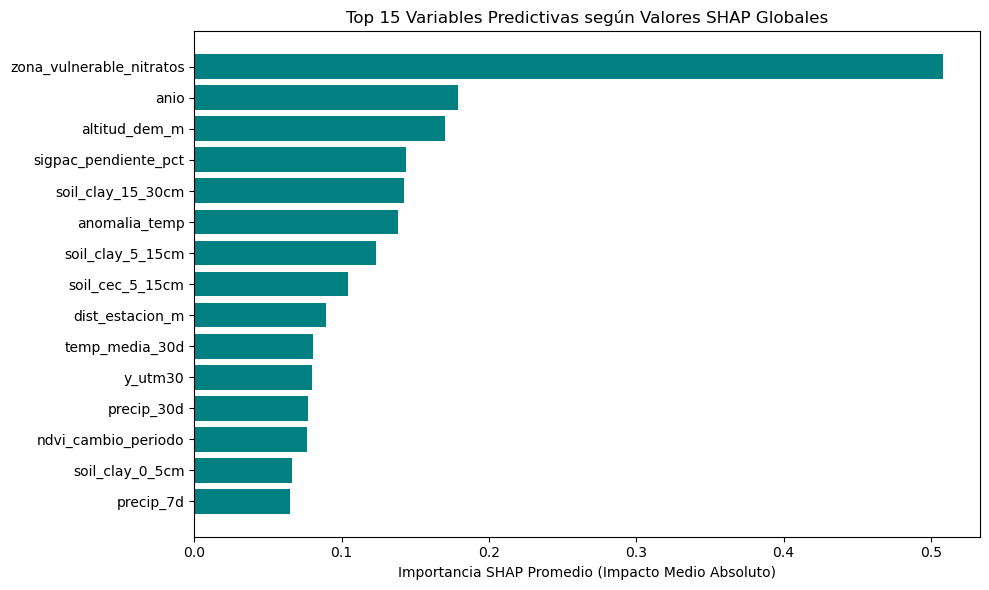

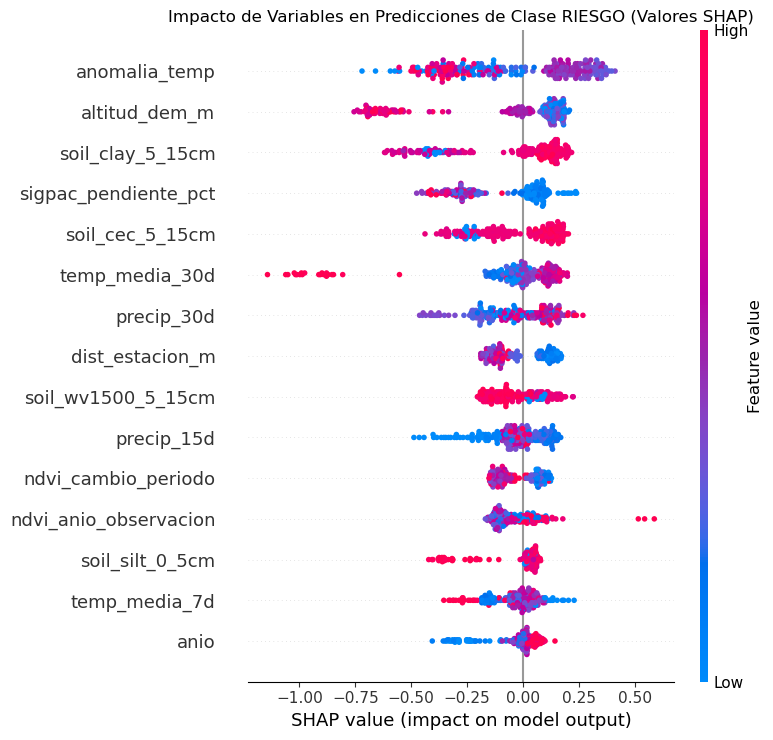

In [16]:
# Gráfico de barras de importancia SHAP global
plt.figure(figsize=(10, 6))
df_shap_plot = df_shap_global.head(15).sort_values("importancia_shap", ascending=True)
plt.barh(df_shap_plot["variable"], df_shap_plot["importancia_shap"], color='teal')
plt.xlabel("Importancia SHAP Promedio (Impacto Medio Absoluto)")
plt.title("Top 15 Variables Predictivas según Valores SHAP Globales")
plt.tight_layout()
plt.show()

# Gráfico summary (beeswarm) para la clase de interés ambiental: RIESGO (índice 2)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_list[2], X_test, max_display=15, show=False)
plt.title("Impacto de Variables en Predicciones de Clase RIESGO (Valores SHAP)", fontsize=12)
plt.tight_layout()
plt.show()

#### 14.5 Agrupación por Familias de Variables
Para facilitar la interpretación científica del modelo por parte de expertos en ciencias de la tierra y del agua, agrupamos las 172 variables (incluyendo las creadas por One-Hot Encoding) en 9 familias lógicas y sumamos su importancia SHAP relativa.

In [17]:
def map_feature_to_family(col_name):
    if any(k in col_name for k in ['precip_', 'temp_media_', 'anomalia_temp', 'evento_extremo_lluvia', 'tmed', 'prec', 'dist_estacion_m']):
        return 'Clima'
    elif col_name.startswith('soil_'):
        return 'Suelo'
    elif col_name.startswith('sigpac_') or col_name.startswith('dist_sigpac_m'):
        return 'Agricultura (SIGPAC)'
    elif col_name.startswith('clc2012_') or col_name.startswith('clc2018_') or col_name == 'cambio_clc_2012_2018':
        return 'Cobertura del suelo (CLC)'
    elif col_name.startswith('ndvi_'):
        return 'Vegetación (NDVI)'
    elif col_name.startswith('municipio_'):
        return 'Espacial (Municipio)'
    elif col_name in ['lat', 'lon', 'altitud_dem_m', 'x_utm30', 'y_utm30', 'altitud']:
        return 'Espacial (Coordenadas)'
    elif col_name in ['anio', 'mes']:
        return 'Temporal (Año/Mes)'
    elif col_name == 'zona_vulnerable_nitratos':
        return 'Territorial (Zona Vulnerable)'
    elif col_name.startswith('naturaleza_') or col_name.startswith('red_'):
        return 'Territorial (Naturaleza/Red)'
    else:
        return 'Otros'

df_shap_global["familia"] = df_shap_global["variable"].apply(map_feature_to_family)
df_shap_families = df_shap_global.groupby("familia")["importancia_shap"].sum().reset_index()
df_shap_families["porcentaje"] = (df_shap_families["importancia_shap"] / df_shap_families["importancia_shap"].sum()) * 100
df_shap_families = df_shap_families.sort_values("importancia_shap", ascending=False).reset_index(drop=True)
df_shap_families["porcentaje_acumulado"] = df_shap_families["porcentaje"].cumsum()

print("=== CONTRIBUCIÓN DE LAS FAMILIAS DE VARIABLES AL MODELO FINAL (SHAP GLOBAL) ===")
print(df_shap_families.round(4).to_string(index=False))

=== CONTRIBUCIÓN DE LAS FAMILIAS DE VARIABLES AL MODELO FINAL (SHAP GLOBAL) ===
                      familia  importancia_shap  porcentaje  porcentaje_acumulado
                        Suelo            1.0059   30.044701             30.044701
                        Clima            0.6044   18.051100             48.095699
Territorial (Zona Vulnerable)            0.5080   15.171300             63.266998
       Espacial (Coordenadas)            0.3492   10.430900             73.697998
         Agricultura (SIGPAC)            0.2451    7.319400             81.017303
            Vegetación (NDVI)            0.2212    6.606300             87.623596
           Temporal (Año/Mes)            0.2204    6.582200             94.205803
    Cobertura del suelo (CLC)            0.1144    3.418200             97.624001
 Territorial (Naturaleza/Red)            0.0796    2.376000            100.000000


### ANÁLISIS ADICIONAL: Ablación de 'zona_vulnerable_nitratos'
Ver nota dejada en Parte 5: evaluar si el modelo depende excesivamente de esta variable, dado su alto peso en SHAP/permutación y su posible circularidad con el target.

In [18]:
carpeta_resultados = Path(
    r"C:\Users\mcangulo\OneDrive - FEDERACION DE EMPRESAS DE LA RIOJA"
    r"\Escritorio\dataset_larioja\11_resultados_modelado"
)

In [19]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, accuracy_score

COL_ZONA = 'zona_vulnerable_nitratos'
assert COL_ZONA in X_train.columns, f"No se encontró la columna {COL_ZONA} en X_train"
idx_riesgo = list(le.classes_).index('riesgo')

X_train_con, X_test_con = X_train.copy(), X_test.copy()
X_train_sin = X_train.drop(columns=[COL_ZONA])
X_test_sin = X_test.drop(columns=[COL_ZONA])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_ablacion = {}

for nombre, X_tr, X_te in [('CON zona_vulnerable_nitratos', X_train_con, X_test_con),
                            ('SIN zona_vulnerable_nitratos', X_train_sin, X_test_sin)]:

    # Mismo modelo ganador de Parte 8 (misma arquitectura/hiperparámetros), clonado sin entrenar
    modelo_cv = clone(best_estimator)
    f1_macro_cv = cross_val_score(modelo_cv, X_tr, y_train_enc, cv=skf, scoring='f1_macro')

    modelo_fit = clone(best_estimator)
    modelo_fit.fit(X_tr, y_train_enc)
    y_pred_test = modelo_fit.predict(X_te)

    resultados_ablacion[nombre] = {
        'n_features': X_tr.shape[1],
        'F1 Macro CV (media)': f1_macro_cv.mean(),
        'F1 Macro CV (std)': f1_macro_cv.std(),
        'F1 Macro Test': f1_score(y_test_enc, y_pred_test, average='macro'),
        'F1 Riesgo Test': f1_score(y_test_enc, y_pred_test, average=None)[idx_riesgo],
        'Accuracy Test': accuracy_score(y_test_enc, y_pred_test),
    }

df_ablacion = pd.DataFrame(resultados_ablacion).T
print("=== TABLA COMPARATIVA: CON vs SIN zona_vulnerable_nitratos ===")
display(df_ablacion.round(4))

# Interpretación automática
f1_con = df_ablacion.loc['CON zona_vulnerable_nitratos', 'F1 Macro Test']
f1_sin = df_ablacion.loc['SIN zona_vulnerable_nitratos', 'F1 Macro Test']
caida_pct = (f1_con - f1_sin) / f1_con * 100

print(f"\nCaída de F1 Macro al quitar la variable: {f1_con - f1_sin:.4f} ({caida_pct:.1f}%)")

if caida_pct < 5:
    print(">>> El modelo NO depende críticamente de 'zona_vulnerable_nitratos': "
          "el resto de variables ambientales mantienen un poder predictivo similar por sí solas.")
else:
    print(">>> El modelo SÍ muestra una dependencia relevante de 'zona_vulnerable_nitratos': "
          "su ausencia reduce notablemente el rendimiento.")

df_ablacion.to_csv(carpeta_resultados / 'ablacion_zona_vulnerable.csv')

=== TABLA COMPARATIVA: CON vs SIN zona_vulnerable_nitratos ===


,n_features,F1 Macro CV (media),F1 Macro CV (std),F1 Macro Test,F1 Riesgo Test,Accuracy Test
CON zona_vulnerable_nitratos,104.0,0.8167,0.0228,0.7916,0.6047,0.8383
SIN zona_vulnerable_nitratos,103.0,0.8085,0.0261,0.7954,0.6207,0.8383



Caída de F1 Macro al quitar la variable: -0.0038 (-0.5%)
>>> El modelo NO depende críticamente de 'zona_vulnerable_nitratos': el resto de variables ambientales mantienen un poder predictivo similar por sí solas.


### 15. Interpretación Científica y Ambiental
El análisis de valores SHAP agrupados por familias muestra que las predicciones del modelo se construyen a partir de una combinación de factores edáficos, climáticos, territoriales, agrícolas y temporales. No obstante, estas contribuciones representan asociaciones predictivas aprendidas por el modelo y no relaciones causales directas.

1. Factores edáficos — Suelo (30,04 %):
Las propiedades del suelo constituyen la familia con mayor contribución global al modelo. Variables como el contenido de arcilla, limo, capacidad de intercambio catiónico, pH, carbono orgánico y capacidad de retención de agua pueden estar relacionadas con la infiltración, movilidad y permanencia de los nitratos en la zona no saturada. Su elevada contribución sugiere que las características edáficas ayudan al modelo a diferenciar contextos con distinto comportamiento frente al transporte de contaminantes.
2. Climatología (18,05 %):
Las variables climáticas, como la precipitación acumulada, la temperatura media y las anomalías térmicas, presentan una influencia relevante en las predicciones. Estas condiciones pueden estar asociadas con procesos de lixiviación, infiltración, recarga y concentración de nitratos. Sin embargo, los resultados SHAP muestran relaciones no lineales, por lo que una mayor precipitación o temperatura no implica necesariamente un incremento uniforme del riesgo.
3. Zona vulnerable a nitratos (15,17 %):
La pertenencia a una zona vulnerable representa una señal territorial importante, ya que estas áreas fueron delimitadas a partir de antecedentes de presión agrícola y contaminación por nitratos. Por ello, la variable resume información histórica y regulatoria relacionada con el fenómeno estudiado. No obstante, el análisis de ablación mostró que, al retirarla y reentrenar el modelo, el rendimiento se mantuvo prácticamente estable. El F1 macro en test pasó de 0,7916 a 0,7954 y la accuracy permaneció en 0,8383. Esto indica que la variable es utilizada de forma relevante por el modelo original, pero no resulta indispensable, ya que el resto de variables ambientales y territoriales conserva una capacidad predictiva similar.
4. Espacialidad — Coordenadas (10,43 %):
La posición geográfica presenta una contribución significativa, lo que confirma que la contaminación por nitratos sigue una distribución territorial. Las coordenadas pueden actuar como indicadores indirectos de condiciones no completamente representadas en el dataset, como características hidrogeológicas locales, orientación del flujo subterráneo, proximidad a zonas agrícolas o diferencias entre masas de agua. Esta dependencia espacial también ayuda a explicar la disminución del rendimiento observada al evaluar puntos IPA completamente nuevos.

6. Espacialidad — Coordenadas (10,43 %):
La posición geográfica presenta una contribución significativa, lo que confirma que la contaminación por nitratos sigue una distribución territorial. Las coordenadas pueden actuar como indicadores indirectos de condiciones no completamente representadas en el dataset, como características hidrogeológicas locales, orientación del flujo subterráneo, proximidad a zonas agrícolas o diferencias entre masas de agua. Esta dependencia espacial también ayuda a explicar la disminución del rendimiento observada al evaluar puntos IPA completamente nuevos.

7. Agricultura — SIGPAC (7,32 %):
Las variables agrícolas, como la pendiente, la superficie de las parcelas, el uso del suelo y el coeficiente de regadío, aportan información sobre la intensidad y las características de la actividad agraria próxima a los puntos de monitoreo. Estas variables pueden funcionar como indicadores indirectos de presión antrópica y del potencial aporte de nitrógeno procedente de fertilizantes y prácticas de riego.

8. Vegetación — NDVI (6,61 %):
Los indicadores de vegetación contribuyen a caracterizar la actividad y evolución de la cobertura vegetal. El NDVI puede reflejar diferencias en productividad agrícola, estacionalidad de los cultivos y cambios en el uso del territorio. Su influencia sobre las predicciones no es uniforme, sino que depende de su interacción con las condiciones climáticas, edáficas y agrícolas.

9. Componente temporal — Año y mes (6,58 %):
Las variables temporales permiten que el modelo capture cambios entre campañas de muestreo, variaciones climáticas anuales y posibles modificaciones en las prácticas agrícolas. Su contribución debe interpretarse con cautela, debido a que el número de observaciones no es uniforme entre años y los puntos monitoreados pueden variar temporalmente.

10. Cobertura del suelo — CORINE Land Cover (3,42 %):
La cobertura del suelo aporta información general sobre el tipo de ocupación territorial, como terrenos agrícolas, viñedos, frutales, regadíos o áreas naturales. Aunque su contribución es inferior a la de SIGPAC, complementa la caracterización del entorno territorial de los puntos de monitoreo.

11. Otras variables territoriales (2,38 %):
Las variables vinculadas con la naturaleza del punto, la masa de agua o la red de monitoreo presentan una contribución menor, pero ayudan a completar el contexto territorial e hidrogeológico disponible.

En conjunto, las familias de suelo y clima concentran aproximadamente el 48 % de la contribución SHAP global. Al incorporar la zona vulnerable y las coordenadas, las cuatro primeras familias reúnen cerca del 74 % de la influencia total del modelo. Esto indica que las predicciones se apoyan principalmente en las características edáficas, las condiciones climáticas y el contexto territorial.

> **Nota Metodológica de Causalidad:** Una variable con elevada importancia SHAP no debe interpretarse automáticamente como una causa directa de la contaminación por nitratos. Los valores SHAP explican cómo las variables modifican las predicciones del modelo y permiten identificar asociaciones predictivas. La confirmación de relaciones causales requiere información complementaria, como datos de fertilización, profundidad de las captaciones, características hidrogeológicas, dirección del flujo subterráneo, análisis hidroquímicos y monitoreos de campo.

### 16. Reentrenamiento Final del Modelo Definitivo
Una vez validadas todas las etapas y reportado el rendimiento imparcial sobre test, el modelo definitivo se entrena utilizando la totalidad de los datos disponibles (unión de train + test). Esto optimiza el uso de la muestra para futuras predicciones, aunque este modelo ya no se vuelve a evaluar estadísticamente.

In [21]:
X_full = pd.concat([X_train, X_test], ignore_index=True)
y_full = pd.concat([pd.Series(y_train_enc), pd.Series(y_test_enc)], ignore_index=True)

if weight_strategy == "weighted":
    final_model = BalancedXGBClassifier(**best_params, random_state=42, eval_metric="mlogloss")
    sample_weight_full = compute_sample_weight(class_weight="balanced", y=y_full)
    final_model.fit(X_full, y_full, sample_weight=sample_weight_full)
else:
    final_model = XGBClassifier(**best_params, random_state=42, eval_metric="mlogloss")
    final_model.fit(X_full, y_full)

print(f"Modelo final definitivo reentrenado con {X_full.shape[0]} muestras del dataset.")

Modelo final definitivo reentrenado con 1172 muestras del dataset.


### 17. Exportación de Modelos e Informes finales
Guardamos los modelos generados, el encoder de etiquetas y todas las tablas e informes de métricas para su uso posterior.

In [22]:
carpeta_resultados = BASE_DIR / '11_resultados_modelado'
carpeta_resultados.mkdir(parents=True, exist_ok=True)

# Guardar archivos binarios
joblib.dump(best_estimator, carpeta_resultados / 'xgboost_evaluado_train.joblib')
joblib.dump(final_model, carpeta_resultados / 'xgboost_final_full_data.joblib')
joblib.dump(le, carpeta_resultados / 'label_encoder.joblib')

# Guardar parámetros
with open(carpeta_resultados / 'mejores_parametros.json', 'w') as f:
    json.dump(best_params, f, indent=4)

# Construir diccionario de estrategia de modelo para guardar
estrategia_modelo = {
    "modelo_seleccionado": "XGBoost",
    "estrategia_ponderacion": weight_strategy,
    "metricas_seleccion": {
        "f1_macro_val_cruzada": float(best_score),
        "std_val_cruzada": float(best_std)
    }
}
with open(carpeta_resultados / 'estrategia_modelo.json', 'w') as f:
    json.dump(estrategia_modelo, f, indent=4)

# Guardar resultados de rendimiento en CSV y JSON
df_cv_results.to_csv(carpeta_resultados / 'resultados_cv_modelos.csv', index=False)

df_cv_ipa = pd.DataFrame({
    "metrica": ["f1_macro_mean", "f1_macro_std", "accuracy_mean", "f1_riesgo_mean", "f1_riesgo_std"],
    "valor": [
        np.mean(res_group['test_f1_macro']),
        np.std(res_group['test_f1_macro']),
        np.mean(res_group['test_accuracy']),
        np.mean(res_group['test_f1_riesgo']),
        np.std(res_group['test_f1_riesgo'])
    ]
})
df_cv_ipa.to_csv(carpeta_resultados / 'resultados_cv_ipa.csv', index=False)

if X_temp_val.shape[0] > 0:
    df_temp_results = pd.DataFrame({
        "metrica": ["accuracy", "balanced_accuracy", "f1_macro", "f1_riesgo"],
        "valor": [
            accuracy_score(y_temp_val, y_pred_temp),
            balanced_accuracy_score(y_temp_val, y_pred_temp),
            f1_score(y_temp_val, y_pred_temp, average="macro"),
            f1_score(y_temp_val, y_pred_temp, average=None)[2]
        ]
    })
    df_temp_results.to_csv(carpeta_resultados / 'resultados_validacion_temporal.csv', index=False)

metricas_test_final = {
    "accuracy": float(acc_test),
    "balanced_accuracy": float(bal_acc_test),
    "precision_macro": float(prec_macro_test),
    "recall_macro": float(rec_macro_test),
    "f1_macro": float(f1_macro_test),
    "f1_afectada": float(f1_clases_test[0]),
    "f1_normal": float(f1_clases_test[1]),
    "f1_riesgo": float(f1_clases_test[2]),
    "precision_riesgo": float(prec_riesgo_test),
    "recall_riesgo": float(rec_riesgo_test)
}
with open(carpeta_resultados / 'metricas_test_final.json', 'w') as f:
    json.dump(metricas_test_final, f, indent=4)

# Guardar tablas de importancias predictivas
df_imp_int.to_csv(carpeta_resultados / 'importancia_xgboost.csv', index=False)
df_imp_perm.to_csv(carpeta_resultados / 'importancia_permutacion.csv', index=False)
df_shap_global.to_csv(carpeta_resultados / 'importancia_shap.csv', index=False)
df_shap_families.to_csv(carpeta_resultados / 'importancia_shap_familias.csv', index=False)

print("Guardado de artefactos de modelado completado.")

Guardado de artefactos de modelado completado.
